### Генерация поэзии с помощью нейронных сетей: шаг 1
##### Автор: [Радослав Нейчев](https://www.linkedin.com/in/radoslav-neychev/), @neychev

Ваша основная задача: научиться генерировать стихи с помощью простой рекуррентной нейронной сети (Vanilla RNN). В качестве корпуса текстов для обучения будет выступать роман в стихах "Евгений Онегин" Александра Сергеевича Пушкина.

In [3]:
# do not change the code in the block below
# __________start of block__________
import string
import os
from random import sample

import numpy as np
import torch, torch.nn as nn
import torch.nn.functional as F

from IPython.display import clear_output

import matplotlib.pyplot as plt
# __________end of block__________

In [4]:
# do not change the code in the block below
# __________start of block__________
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print('{} device is available'.format(device))
# __________end of block__________

cuda device is available


#### 1. Загрузка данных.

In [5]:
# do not change the code in the block below
# __________start of block__________
!wget https://raw.githubusercontent.com/neychev/small_DL_repo/master/datasets/onegin.txt

with open('onegin.txt', 'r') as iofile:
    text = iofile.readlines()

text = "".join([x.replace('\t\t', '').lower() for x in text])
# __________end of block__________

--2026-02-18 17:41:35--  https://raw.githubusercontent.com/neychev/small_DL_repo/master/datasets/onegin.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 262521 (256K) [text/plain]
Saving to: ‘onegin.txt’

onegin.txt          100%[===================>] 256.37K  --.-KB/s    in 0.02s   

2026-02-18 17:41:36 (14.9 MB/s) - ‘onegin.txt’ saved [262521/262521]



#### 2. Построение словаря и предобработка текста
В данном задании требуется построить языковую модель на уровне символов. Приведем весь текст к нижнему регистру и построим словарь из всех символов в доступном корпусе текстов. Также добавим токен `<sos>`.

In [6]:
# print(text)

In [7]:
# do not change the code in the block below
# __________start of block__________
tokens = sorted(set(text.lower())) + ['<sos>']
num_tokens = len(tokens)

assert num_tokens == 84, "Check the tokenization process"

token_to_idx = {x: idx for idx, x in enumerate(tokens)}
idx_to_token = {idx: x for idx, x in enumerate(tokens)}

assert len(tokens) == len(token_to_idx), "Mapping should be unique"

print("Seems fine!")


text_encoded = [token_to_idx[x] for x in text]
# __________end of block__________

Seems fine!


__Ваша задача__: обучить классическую рекуррентную нейронную сеть (Vanilla RNN) предсказывать следующий символ на полученном корпусе текстов и сгенерировать последовательность длины 100 для фиксированной начальной фразы.

Вы можете воспользоваться кодом с занятие №6 или же обратиться к следующим ссылкам:
* Замечательная статья за авторством Andrej Karpathy об использовании RNN: [link](http://karpathy.github.io/2015/05/21/rnn-effectiveness/)
* Пример char-rnn от Andrej Karpathy: [github repo](https://github.com/karpathy/char-rnn)
* Замечательный пример генерации поэзии Шекспира: [github repo](https://github.com/spro/practical-pytorch/blob/master/char-rnn-generation/char-rnn-generation.ipynb)

Данное задание является достаточно творческим. Не страшно, если поначалу оно вызывает затруднения. Последняя ссылка в списке выше может быть особенно полезна в данном случае.

Далее для вашего удобства реализована функция, которая генерирует случайный батч размера `batch_size` из строк длиной `seq_length`. Вы можете использовать его при обучении модели.

In [8]:
# do not change the code in the block below
# __________start of block__________
batch_size = 256
seq_length = 100
start_column = np.zeros((batch_size, 1), dtype=int) + token_to_idx['<sos>']

def generate_chunk():
    global text_encoded, start_column, batch_size, seq_length

    start_index = np.random.randint(0, len(text_encoded) - batch_size*seq_length - 1)
    data = np.array(text_encoded[start_index:start_index + batch_size*seq_length]).reshape((batch_size, -1))
    yield np.hstack((start_column, data))
# __________end of block__________

Пример батча:

In [9]:
chunk = next(generate_chunk())
chunk.shape

(256, 101)

Далее вам предстоит написать код для обучения модели и генерации текста.

In [10]:
# your beautiful experiments here

class RNN(nn.Module):
  def __init__(self, input_size, hidden_size, output_size, num_layers=1):
    super(RNN, self).__init__()
    self.input_size = input_size
    self.hidden_size = hidden_size
    self.output_size = output_size
    self.num_layers = num_layers

    self.encoding = nn.Embedding(num_embeddings=input_size,
                                 embedding_dim=hidden_size,)

    self.rnn = nn.RNN(input_size=hidden_size,
                      hidden_size=hidden_size,
                      num_layers=num_layers,
                      batch_first = True,
                      )
    self.decoding = nn.Linear(in_features=hidden_size,
                              out_features=output_size)

  def forward(self, x):
    input = self.encoding(x)
    out, hidden = self.rnn(input)
    decoded = self.decoding(out)
    return decoded


In [16]:
vocab_size, output_size = num_tokens, num_tokens
hidden_size = 128
num_layers=1
model = RNN(input_size=vocab_size,
            hidden_size=hidden_size,
            output_size=vocab_size,
            num_layers=1)
model.to(device)
chunk = torch.tensor(chunk)
chunk = chunk.to(device)
output = model(chunk)
print(output.size())

/tmp/ipython-input-20913681.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  chunk = torch.tensor(chunk)


torch.Size([256, 101, 84])


In [12]:
chunk[:, 1:]

tensor([[47, 50, 55,  ..., 45, 61, 64],
        [ 1, 62, 47,  ..., 73,  1, 53],
        [66,  1, 58,  ...,  7,  0, 64],
        ...,
        [53,  5,  1,  ..., 58, 45,  1],
        [62, 55, 45,  ..., 64, 68, 50],
        [58, 53, 54,  ...,  1, 62, 56]])

In [17]:
from tqdm import tqdm

def train(model, num_steps, ):
  model.train()
  losses = []
  loss_func = nn.CrossEntropyLoss()
  optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)
  for i in tqdm(range(num_steps)):
    chunk = torch.tensor(next(generate_chunk()))
    input = chunk[:, :-1].to(device)
    target = chunk[:, 1:].to(device)

    optimizer.zero_grad()
    # print(model(input))
    output = model(input)
    # print(f'target size {target.size()}')
    # print(f'output size {output.size()}')

    loss = loss_func(output.reshape(-1, vocab_size), target.reshape(-1))
    losses.append(loss.item())
    loss.backward()
    optimizer.step()
    if i % 100 == 0:
      print(f'\n step #{i+1} loss value: {loss.item()}')
  return losses


In [18]:
losses = train(model, 5000)

  0%|          | 16/5000 [00:00<02:07, 39.04it/s]


 step #1 loss value: 4.473398685455322


  3%|▎         | 134/5000 [00:01<00:27, 179.97it/s]


 step #101 loss value: 2.5391170978546143


  5%|▍         | 239/5000 [00:01<00:23, 202.13it/s]

...

 96%|█████████▋| 4822/5000 [00:24<00:00, 207.87it/s]


 step #4801 loss value: 1.7731106281280518


 99%|█████████▊| 4928/5000 [00:25<00:00, 205.47it/s]


 step #4901 loss value: 1.78961980342865


100%|██████████| 5000/5000 [00:25<00:00, 193.85it/s]


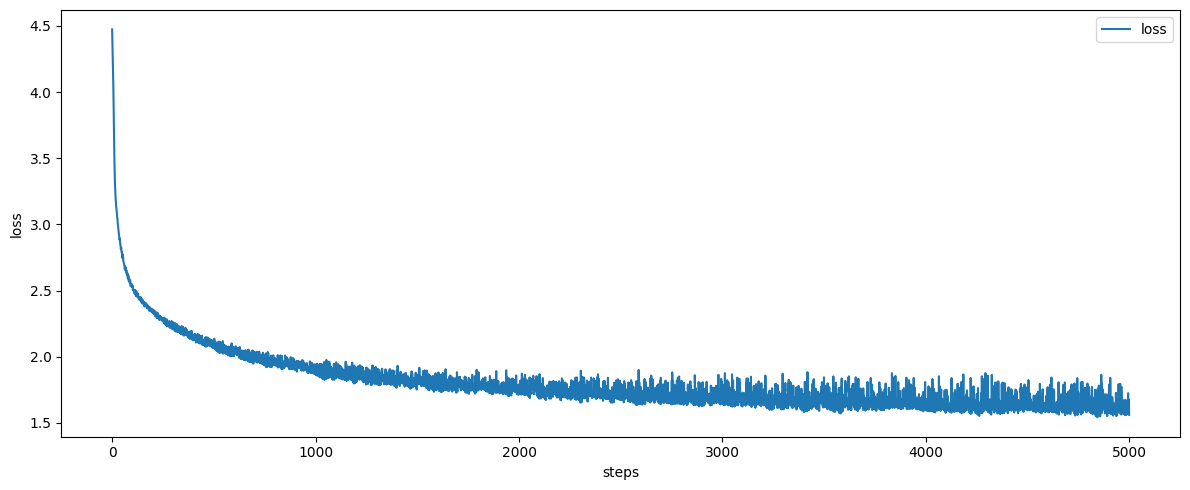

In [28]:
fig = plt.figure(figsize=(12,5))
plt.xlabel('steps')
plt.ylabel('loss')
plt.plot(losses, label='loss')
plt.legend()
plt.tight_layout()
plt.show()

В качестве иллюстрации ниже доступен график значений функции потерь, построенный в ходе обучения авторской сети (сам код для ее обучения вам и предстоит написать).

Шаблон функции `generate_sample` также доступен ниже. Вы можете как дозаполнить его, так и написать свою собственную функцию с нуля. Не забывайте, что все примеры в обучающей выборке начинались с токена `<sos>`.

In [85]:
def generate_sample(char_rnn, seed_phrase=None, max_length=200, temperature=1.0, device=device):
    '''
    The function generates text given a phrase of length at least SEQ_LENGTH.
    :param seed_phrase: prefix characters. The RNN is asked to continue the phrase
    :param max_length: maximum output length, including seed_phrase
    :param temperature: coefficient for sampling.  higher temperature produces more chaotic outputs,
                        smaller temperature converges to the single most likely output
    '''
    char_rnn.eval()
    if seed_phrase is not None:
        x_sequence = [token_to_idx['<sos>']] + [token_to_idx[token] for token in seed_phrase]
    else:
        x_sequence = [token_to_idx['<sos>']]
    x_sequence_len = len(x_sequence)
    x_sequence = torch.tensor([x_sequence], dtype=torch.int64).to(device)

    #feed the seed phrase, if any
    with torch.no_grad():
      for i in range(max_length - x_sequence_len+1):
        input = torch.tensor(x_sequence).to(device)
        output = char_rnn(input)
        last_char_logits = output[0, -1, :] # берем предсказание для последнего символа в тексте
        last_char_logits_scaled = last_char_logits / temperature # применяем температуру
        last_char_probs = F.softmax(last_char_logits_scaled, dim=-1)
        selected_token_idx = torch.multinomial(last_char_probs, num_samples=1) # вычисляем с учетом вероятностей индекс следующего токена
        x_sequence_len += 1
        x_sequence = torch.concat((x_sequence, selected_token_idx.unsqueeze(1, )), dim=1,)

    return ''.join([tokens[ix] for ix in x_sequence.cpu().data.numpy()[0]])

30

Пример текста сгенерированного обученной моделью доступен ниже. Не страшно, что в тексте много несуществующих слов. Используемая модель очень проста: это простая классическая RNN.

In [73]:
print(generate_sample(model, ' мой дядя самых честных правил', max_length=500, temperature=0.8))

/tmp/ipython-input-2175666010.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input = torch.tensor(x_sequence).to(device)


<sos> мой дядя самых честных правильный света,
к переветную проволость деревне свои в эти города
и ж том да, в ней.
двартная, как то скакать ловец,
их поэта:
пойду таковся вас жизни их был здол ноков редетки отставится взгрущит мой угала молчать дни страший, головие привыктишь?
комнень мой дума своей приезжала?» —
«так онегины стишине
скогда-нибупельцая шутит и страшно намает
своей по досельный без свершил.
снет,
и в суббуги пустяние ленский на потрез нем, тузами,
лицо:
не уж и восторовой и шепку во


In [80]:
for temper in np.arange(0.1, 1.5, 0.2):
  print(temper)
  print(generate_sample(model,
                        ' мой дядя самых честных правил',
                        max_length=500,
                        temperature=temper),
                        )

0.1


/tmp/ipython-input-2175666010.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input = torch.tensor(x_sequence).to(device)


<sos> мой дядя самых честных правильной сон простите и был с ней сердце желали с как молча быть он на света
меня в сердце страстной доле в достой,
как был с как бы в по много в том он сердце старины.
подна уж был с ней на свете страстной читала слезами между – всё том онегину дело постели свет,
и в сердце приветки подавал поражный своей долго в том он в сердце старины.
подна уж без волной странной страстной нет в отрада,
под ним старины.
но в сем и слез и страшно последний страстной нет в ответа
мне
0.30000000000000004
<sos> мой дядя самых честных правильной челько страстной долет ним последноги погружен,
и не призовли модной приверческого в том полной волной занясь, безумный,
приходит
надежда,
и на пора в по больше нежилее тебя порогом
и страстный свой своей ветер с красно в одно уморов молодный мой деве города и не скучительной долет и страшной сторон, как без велить меня в нас любовь ее столькое странной нашей последний страстной не скать унылый,
и в ней сердцем у купый волной света

### Сдача задания
Сгенерируйте десять последовательностей длиной 500, используя строку ' мой дядя самых честных правил'. Температуру для генерации выберите самостоятельно на основании визуального качества генериуремого текста. Не забудьте удалить все технические токены в случае их наличия.

Сгенерированную последовательность сохрание в переменную `generated_phrase` и сдайте сгенерированный ниже файл в контест.

In [81]:
seed_phrase = ' мой дядя самых честных правил'

In [86]:
# generated_phrases = # your code here

# # For example:

generated_phrases = [
    generate_sample(
        model,
        ' мой дядя самых честных правил',
        max_length=500,
        temperature=0.3
    ).replace('<sos>', '')
    for _ in range(10)
]

/tmp/ipython-input-4290102892.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input = torch.tensor(x_sequence).to(device)


In [88]:
# do not change the code in the block below
# __________start of block__________

import json
if 'generated_phrases' not in locals():
    raise ValueError("Please, save generated phrases to `generated_phrases` variable")

for phrase in generated_phrases:

    if not isinstance(phrase, str):
        raise ValueError("The generated phrase should be a string")
    # print(len(phrase))
    if len(phrase) != 500:
        raise ValueError("The `generated_phrase` length should be equal to 500")

    assert all([x in set(tokens) for x in set(list(phrase))]), 'Unknown tokens detected, check your submission!'


submission_dict = {
    'token_to_idx': token_to_idx,
    'generated_phrases': generated_phrases
}

with open('submission_dict.json', 'w') as iofile:
    json.dump(submission_dict, iofile)
print('File saved to `submission_dict.json`')
# __________end of block__________

File saved to `submission_dict.json`


На этом задание завершено. Поздравляем!